# Bike-Sharing Rental Project

# 1. Exploratory Data Ananlysis(EDA)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

In [2]:
df = pd.read_csv("Dataset.csv")

# Understanding Dataset Better

In [3]:
df.shape

(17379, 17)

In [4]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


# Replace '?' with NaN

In [6]:
df.replace('?', np.nan, inplace=True)

# Handling Data Types

In [7]:
num_cols = ['temp','atemp','hum','windspeed','casual','registered']
df[num_cols] = df[num_cols].apply(pd.to_numeric)
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)
cat_cols = ['season','yr','mnth','holiday','workingday','weathersit']
df[cat_cols] = df[cat_cols].astype('category')

# Checking Null Values

In [8]:
df.isnull().sum()

instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

# Handling Null Values

In [9]:
num_cols = ['temp','atemp','hum','windspeed','casual','registered']
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))
cat_cols = ['season','yr','mnth','holiday','workingday','weathersit']
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Replacing Springer with Spring

In [10]:
df['season'] = df['season'].cat.rename_categories({'springer': 'spring'})

# Check Duplicate Records

In [11]:
df.duplicated().sum()

np.int64(0)

# Checking Business Logic

In [12]:
(df['casual'] + df['registered'] == df['cnt']).value_counts()

True     17378
False        1
Name: count, dtype: int64

# Correcting Business Logic

In [13]:
df.loc[df['casual'] + df['registered'] != df['cnt'], 'cnt'] = \
df['casual'] + df['registered']

# Rechecking

In [14]:
(df['casual'] + df['registered'] == df['cnt']).value_counts()

True    17379
Name: count, dtype: int64

# Outlier Detection in continuous variables

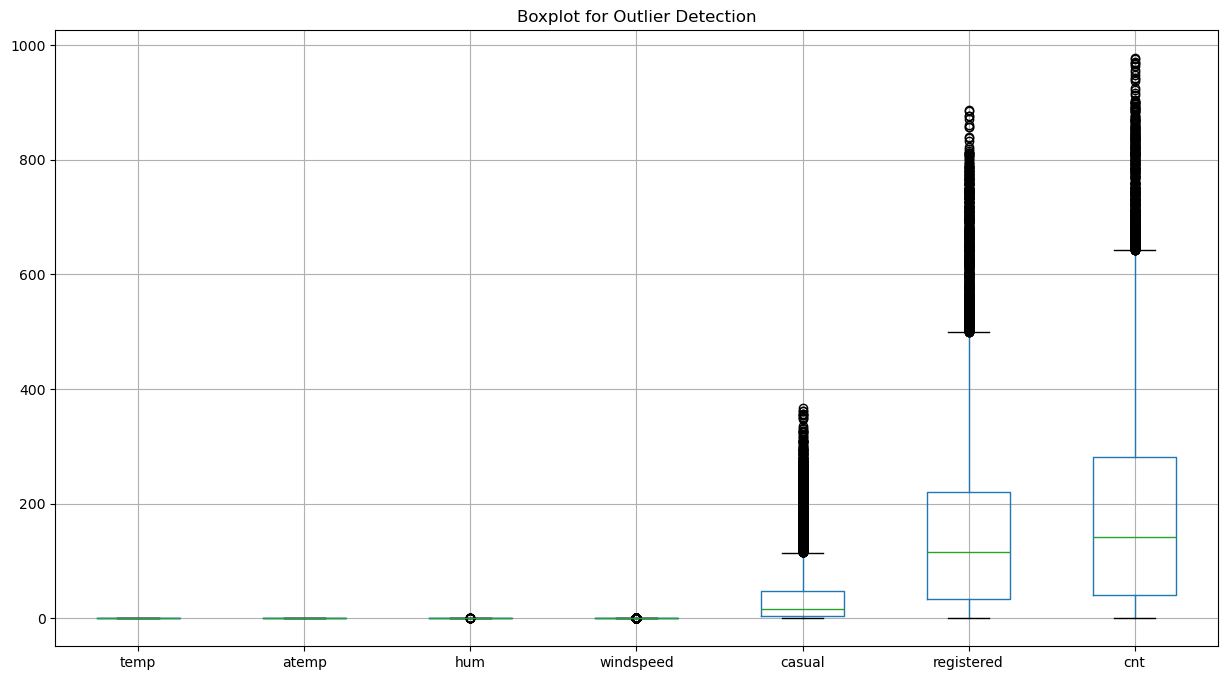

In [15]:
outlier_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
plt.figure(figsize=(15,8))
df[outlier_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

#### 1) Boxplots shows a large number of outliers in casual, registered, and total bike rentals. 
#### 2) These values represent peak-demand scenarios influenced by time, weather, and user behavior. 
#### 3) Since these observations are critical for demand prediction, the outliers were retained rather than removed.

# 2. Data Visualization

# Distribution Plot

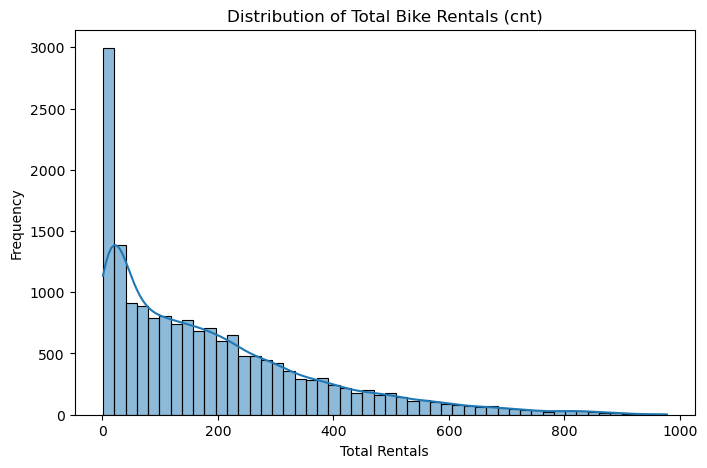

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], bins=50, kde=True)
plt.title("Distribution of Total Bike Rentals (cnt)")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")
plt.show()

#### 1) It shows right skewed distribution.
#### 2) It indicates level of bike renting happens in moderate levels and high demand is rare.

# Casual Users vs Registered Users

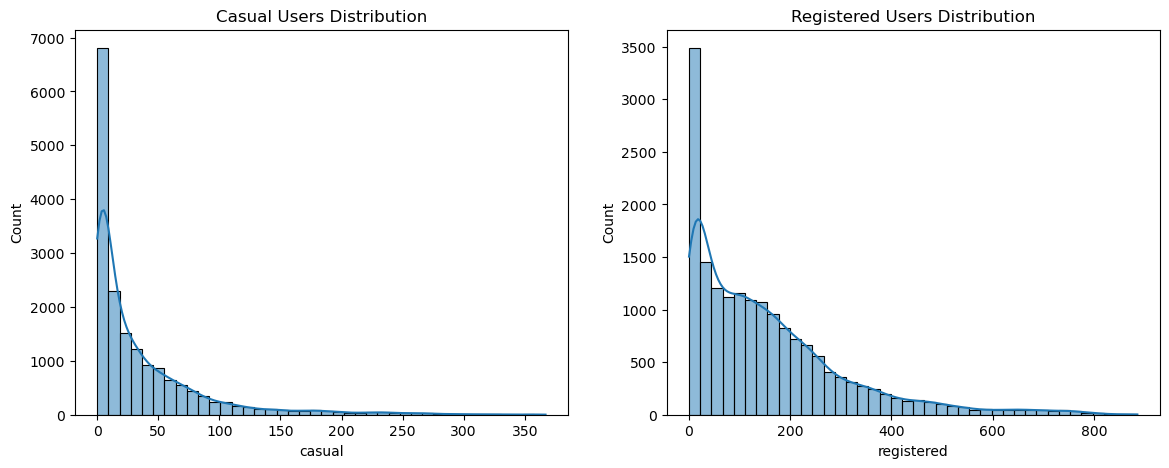

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['casual'], bins=40, kde=True, ax=ax[0])
ax[0].set_title("Casual Users Distribution")
sns.histplot(df['registered'], bins=40, kde=True, ax=ax[1])
ax[1].set_title("Registered Users Distribution")
plt.show()

#### 1) It shows behaviour of casual and registered users in bike renting.
#### 2) As we see, registered users dominate total demand. And casual users show a particular pattern in demand.

# Weather Focused Distribution

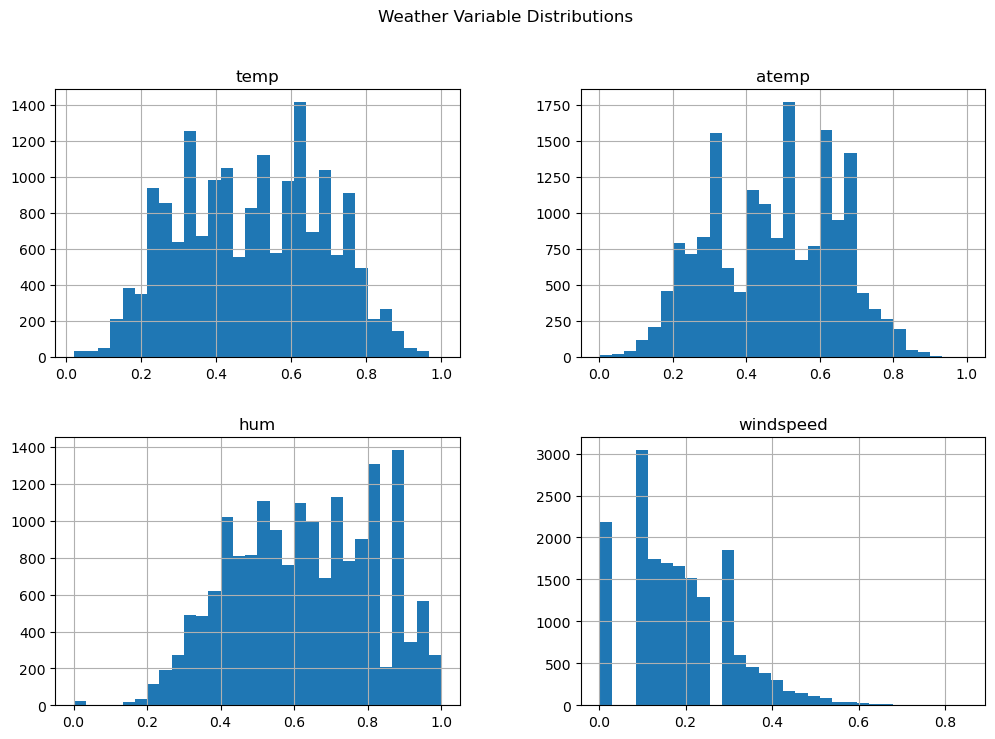

In [18]:
weather_cols = ['temp','atemp','hum','windspeed']
df[weather_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Weather Variable Distributions")
plt.show()

#### 1) The temp(Temperature) and atemp graphs look stable and normally distributed.
#### 2) The humidity graph is left skewed indicating high demand when humidity is high.
#### 3) While windspeed graph is right skewed indicating high demand in low windspeed.

# Season Focused Distribution

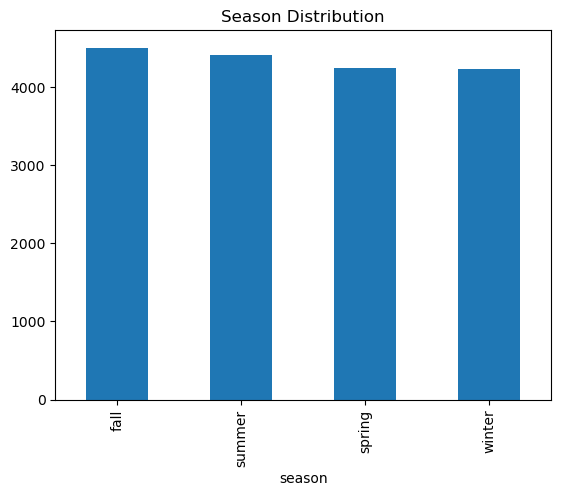

In [19]:
df['season'].value_counts().plot(kind='bar', title='Season Distribution')
plt.show()

#### There is high demand in fall season and low demand in spring.

# Time vs Demand

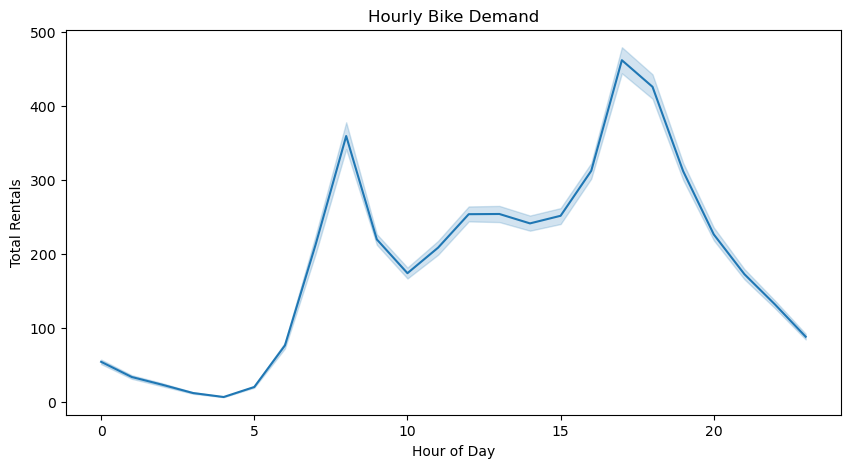

In [20]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='cnt', data=df)
plt.title("Hourly Bike Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Total Rentals")
plt.show()

#### 1) As the morning approaches around 6 am, the demand moves up.
#### 2) The evening time between 4 pm to 8 pm is peek hour for bike rentals.

# Working Day vs Demand

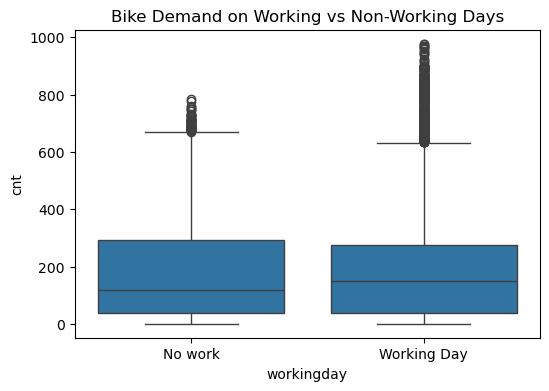

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='workingday', y='cnt', data=df)
plt.title("Bike Demand on Working vs Non-Working Days")
plt.show()

#### 1) There is high flucation during working days in demand of bikes.
#### 2) During non-working days also there is demand for bikes but with less variation.

# Weather vs Demand

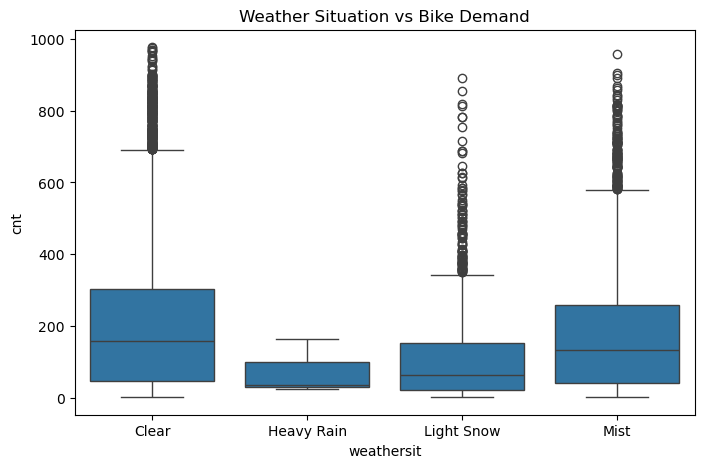

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title("Weather Situation vs Bike Demand")
plt.show()

#### 1) High demand is seen in clear weather as well as in presence of mist.
#### 2) In heavy rainfall conditions demand decreases.

# Temperature vs Demand

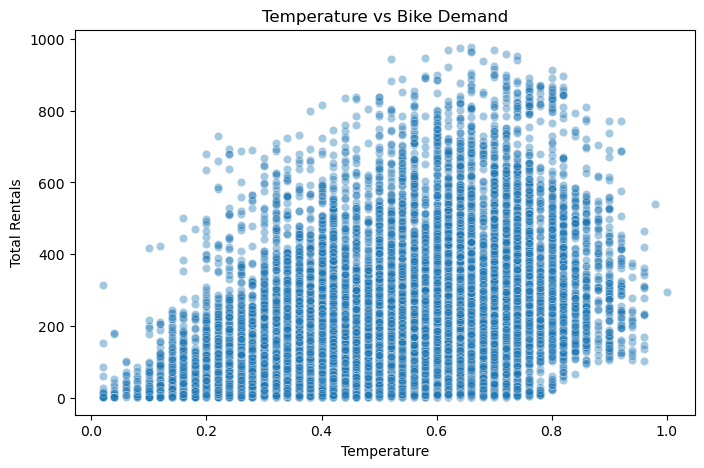

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=df, alpha=0.4)
plt.title("Temperature vs Bike Demand")
plt.xlabel("Temperature")
plt.ylabel("Total Rentals")
plt.show()

#### 1) In moderate temperature the demand is high.
#### 2) In extreme temperature the demand is low.

# Humidity vs Demand

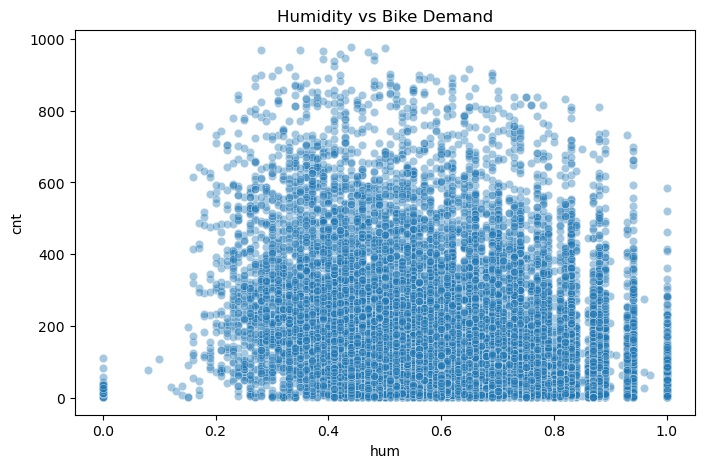

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='hum', y='cnt', data=df, alpha=0.4)
plt.title("Humidity vs Bike Demand")
plt.show()

#### 1) In moderate humidity the demand is high.
#### 2) In extreme humidity the demand is low.

# Correlation Map

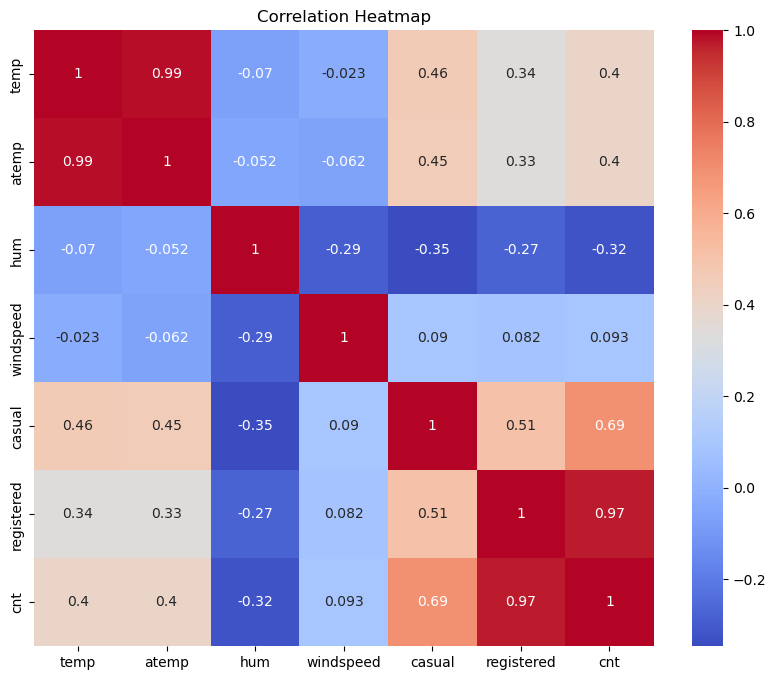

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['temp','atemp','hum','windspeed','casual','registered','cnt']].corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### 1) The total rent is less likely dependent on humidity factor.
#### 2) It liekly depends on temperature to some extent. Also the registered users are more than casual users.

# Feature Engineering

In [26]:
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x in [0,6] else 0)
def hour_category(hr):
    if 5 <= hr < 12:
        return 'Morning'
    elif 12 <= hr < 17:
        return 'Afternoon'
    elif 17 <= hr < 21:
        return 'Evening'
    else:
        return 'Night'

df['hour_category'] = df['hr'].apply(hour_category)
df['is_peak_hour'] = df['hr'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)
df['comfort_index'] = df['temp'] * (1 - df['hum'])

#### 1) If weekend(Saturday or Sunday) then 1 else 0.
#### 2) For hours the hour category is added like 5 am to 11 am is Morning,12 noon to 4 pm is Afternoon, 5 pm to 8 pm is Evening
####    and 9 pm to 4 am is Night
#### 3) The peak hours are 7,8,9 in morning and 5,6,7 in evening so peak hour category added.
#### 4) The perfect comfort condition for bike rental is categorized by using temperature and humidity.

In [27]:
df['day'] = df['dteday'].dt.day
df['month_from_date'] = df['dteday'].dt.month
df['year_from_date'] = df['dteday'].dt.year
df.drop('dteday', axis=1, inplace=True)

# Encoding Categorial Variables

In [28]:
cat_features = [
    'season', 'weathersit', 'holiday',
    'workingday', 'hour_category','yr','mnth'
]
df = pd.get_dummies(df, columns=cat_features, drop_first=True)

# Model Building

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

## Define Target Variable

In [30]:
X = df.drop('cnt', axis=1)
y = df['cnt']

## Split data into Training and Testing Data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Initialization

In [32]:
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)
lr_model = LinearRegression()
xgb_model = XGBRegressor(n_estimators=200,learning_rate=0.1,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42)

## Train all the above models

In [33]:
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

## Evaluate Models

In [34]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return rmse, mae, r2
print("Evaluation of Decision Tree:")
dt_rmse, dt_mae, dt_r2 = evaluate_model(dt_model, X_test, y_test)
dt_rmse, dt_mae, dt_r2

Evaluation of Decision Tree:


(np.float64(5.254949992590415), 2.3757192174913695, 0.9991279286054044)

In [35]:
print("Evaluation of Random Forest:")
rf_rmse, rf_mae, rf_r2 = evaluate_model(rf_model, X_test, y_test)
rf_rmse, rf_mae, rf_r2

Evaluation of Random Forest:


(np.float64(2.881369878424946), 1.0116426927502875, 0.9997378119523515)

In [36]:
print("Evaluation of Gradient Boosting:")
gb_rmse, gb_mae, gb_r2 = evaluate_model(gb_model, X_test, y_test)
gb_rmse, gb_mae, gb_r2

Evaluation of Gradient Boosting:


(np.float64(5.054322463671617), 3.0950808219968784, 0.9991932466849921)

In [37]:
print("Evaluation of Linear Regression:")
lr_rmse, lr_mae, lr_r2 = evaluate_model(lr_model, X_test, y_test)
lr_rmse, lr_mae, lr_r2

Evaluation of Linear Regression:


(np.float64(2.8649006156604745e-11), 2.473315009518174e-11, 1.0)

In [38]:
print("Evaluation of XGBoost Model:")
xgb_rmse, xgb_mae, xgb_r2 = evaluate_model(xgb_model, X_test, y_test)
xgb_rmse, xgb_mae, xgb_r2

Evaluation of XGBoost Model:


(np.float64(5.614749129848786), 3.341688394546509, 0.9990044236183167)

## Model Comparison Table

In [39]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree','Random Forest','Gradient Boosting','XGBoost'],
    'RMSE': [round(lr_rmse,2),round(dt_rmse,2),round(rf_rmse,2),round(gb_rmse,2),round(xgb_rmse,2)],
    'MAE': [round(lr_mae,2),round(dt_mae,2),round(rf_mae,2),round(gb_mae,2),round(xgb_mae,2)],
    'R2 Score': [lr_r2,dt_r2,rf_r2,gb_r2,xgb_r2]
})

model_results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,0.00,0.00,1.000000
1,Decision Tree,5.25,2.38,0.999128
2,Random Forest,2.88,1.01,0.999738
3,Gradient Boosting,5.05,3.10,0.999193
4,XGBoost,5.61,3.34,0.999004


### 1) The R2 scores occur perfect which is problematic as it is not possible with real world data.
### 2) The perfect score indicates data leakage.
### 3) The business logic casual users + registered users = total(cnt) causes target leakage.

# Drop Leakage Columns

In [40]:
df_model = df.drop(['casual', 'registered'], axis=1)
X = df_model.drop('cnt', axis=1)
y = df_model['cnt']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)
lr_model = LinearRegression()
xgb_model = XGBRegressor(n_estimators=200,learning_rate=0.1,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42)

In [41]:
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return rmse, mae, r2
print("Evaluation of Decision Tree:")
dt_rmse, dt_mae, dt_r2 = evaluate_model(dt_model, X_test, y_test)
dt_rmse, dt_mae, dt_r2

Evaluation of Decision Tree:


(np.float64(57.94591690996225), 33.313291139240505, 0.8939622400334822)

In [42]:
print("Evaluation of Random Forest:")
rf_rmse, rf_mae, rf_r2 = evaluate_model(rf_model, X_test, y_test)
rf_rmse, rf_mae, rf_r2

Evaluation of Random Forest:


(np.float64(39.21045189049531), 23.74120253164557, 0.9514467214361826)

In [43]:
print("Evaluation of Gradient Boosting:")
gb_rmse, gb_mae, gb_r2 = evaluate_model(gb_model, X_test, y_test)
gb_rmse, gb_mae, gb_r2

Evaluation of Gradient Boosting:


(np.float64(63.24277024705897), 43.46928430562974, 0.8736903195090522)

In [44]:
print("Evaluation of Linear Regression:")
lr_rmse, lr_mae, lr_r2 = evaluate_model(lr_model, X_test, y_test)
lr_rmse, lr_mae, lr_r2

Evaluation of Linear Regression:


(np.float64(106.71647346451843), 79.45151669819737, 0.6403518783414106)

In [45]:
print("Evaluation of XGBoost Model:")
xgb_rmse, xgb_mae, xgb_r2 = evaluate_model(xgb_model, X_test, y_test)
xgb_rmse, xgb_mae, xgb_r2

Evaluation of XGBoost Model:


(np.float64(36.351600278026794), 22.85787582397461, 0.9582687020301819)

In [46]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree','Random Forest','Gradient Boosting','XGBoost'],
    'RMSE': [round(lr_rmse,2),round(dt_rmse,2),round(rf_rmse,2),round(gb_rmse,2),round(xgb_rmse,2)],
    'MAE': [round(lr_mae,2),round(dt_mae,2),round(rf_mae,2),round(gb_mae,2),round(xgb_mae,2)],
    'R2 Score': [lr_r2,dt_r2,rf_r2,gb_r2,xgb_r2]
})

model_results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,106.72,79.45,0.640352
1,Decision Tree,57.95,33.31,0.893962
2,Random Forest,39.21,23.74,0.951447
3,Gradient Boosting,63.24,43.47,0.873690
4,XGBoost,36.35,22.86,0.958269


#### 1) Linear Regression Model acts like a BaseLine Model and fails to capture non-linear relationship between total rent and weather,season etc.
#### 2) Decision Tree captures non-linear relationship but is not stable.
#### 3) Random Forest suits best for the dataset and handles complex interaction effectively.
#### 4) Gradient Boosting works better but is sensitive to noise and parameter settings.
#### 5) XGBoost gives the best performance by efficiently handling complex non-linear relationships and reducing bias and variance.

# Hyperparameter Tuning

In [47]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Parameter Grid for Decision Tree

In [48]:
dt_param_grid = {
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 4]
}

## Grid Search with Cross Validation

In [49]:
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, 40],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [10, 15, 20]},
             scoring='r2')

## Evaluate Tuned Decisison Tree

In [50]:
best_dt = dt_grid.best_estimator_
evaluate_model(best_dt, X_test, y_test)

(np.float64(51.20370512078131), 30.825158412262844, 0.917202420324242)

In [51]:
dt_grid.best_estimator_

DecisionTreeRegressor(max_depth=30, min_samples_leaf=4, min_samples_split=15,
                      random_state=42)

#### By tuning parameters the r2 score increased from 0.89 to 0.92 of decision tree indicating reduction in overfitting.

### Parameter Grid for XGBoost

In [52]:
xgb_param_dist = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [5, 7, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

### Randomized Search with CV

In [53]:
xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
xgb_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'learning_rate': [0.05, 0.1, 0.2],
                                        'max_depth': [5, 7, 9],
                                        'n_estimators': [300, 400, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='r2')

In [54]:
best_xgb = xgb_random.best_estimator_
evaluate_model(best_xgb, X_test, y_test)

(np.float64(34.307198759425845), 21.01044273376465, 0.9628306031227112)

In [55]:
xgb_random.best_estimator_

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

#### By tuning parameters the r2 score increased from 0.958 to 0.963 of XGBoost indicating better capturing of non-linear relationships and thus acquiring optimal results.

### Parameter Grid for Random Forest

In [56]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [20, 30],
    'min_samples_split': [1, 2],
    'min_samples_leaf': [1, 2]
}

### Randomized Search with CV

In [57]:
from sklearn.exceptions import FitFailedWarning
import warnings
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [58]:
rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [20, 30],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [1, 2],
                                        'n_estimators': [100, 150]},
                   random_state=42, scoring='r2')

In [59]:
best_rf = rf_search.best_estimator_
evaluate_model(best_rf, X_test, y_test)

(np.float64(39.064041167779685), 23.698513607178736, 0.9518086376284938)

In [60]:
rf_search.best_params_

{'n_estimators': 150,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 30}

In [61]:
rf_search.best_estimator_

RandomForestRegressor(max_depth=30, n_estimators=150, n_jobs=-1,
                      random_state=42)

#### By tuning parameters of Random Forest the r2 score increased from 0.952 to 0.952 thus slightly improving.

### Parameter Grid for Gradient Boosting

In [62]:
gb = GradientBoostingRegressor(random_state=42)
gb_params = {
    'n_estimators': [100, 150],
    'learning_rate': [0.1, 0.2],
    'max_depth': [9, 11],
    'subsample': [0.6, 0.8]
}

### Randomized Search with CV

In [63]:
gb_search = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=8,
    cv=3,
    scoring='r2',
    random_state=42
)
gb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=8,
                   param_distributions={'learning_rate': [0.1, 0.2],
                                        'max_depth': [9, 11],
                                        'n_estimators': [100, 150],
                                        'subsample': [0.6, 0.8]},
                   random_state=42, scoring='r2')

In [64]:
best_gb = gb_search.best_estimator_
evaluate_model(best_gb, X_test, y_test)

(np.float64(34.87607510855676), 20.91956265182548, 0.9615877209977277)

In [65]:
gb_search.best_params_

{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.1}

In [66]:
gb_search.best_estimator_

GradientBoostingRegressor(max_depth=9, random_state=42, subsample=0.8)

#### By tuning parameters of Gradient Boosting the r2 score increased from 0.87 to 0.961 incidating that it is highly sensitive to parameters and hence proper values can make it optimal and reduce overfitting.

## Model Evaluation

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [68]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return rmse, mae, r2

In [69]:
results = []
# Linear Regression
rmse, mae, r2 = evaluate_model(lr_model, X_test, y_test)
results.append(["Linear Regression", rmse, mae, r2])
# Decision Tree
rmse, mae, r2 = evaluate_model(best_dt, X_test, y_test)
results.append(["Decision Tree", rmse, mae, r2])
# Random Forest
rmse, mae, r2 = evaluate_model(best_rf, X_test, y_test)
results.append(["Random Forest", rmse, mae, r2])
# Gradient Boosting
rmse, mae, r2 = evaluate_model(best_gb, X_test, y_test)
results.append(["Gradient Boosting", rmse, mae, r2])
# XGBoost
rmse, mae, r2 = evaluate_model(best_xgb, X_test, y_test)
results.append(["XGBoost", rmse, mae, r2])

In [70]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "R2 Score"]
)
results_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,106.716473,79.451517,0.640352
1,Decision Tree,51.203705,30.825158,0.917202
2,Random Forest,39.064041,23.698514,0.951809
3,Gradient Boosting,34.876075,20.919563,0.961588
4,XGBoost,34.307199,21.010443,0.962831


### 1) The best model among the above is XGBoost. It has highest R2 score and lowest RMSE.
### 2) It captures relationship, handles bias-variance tradeoff efficiently.
### 3) Gradient Boosting can be the strongest alternative for XGBoost as it also showed better performance after tuning.

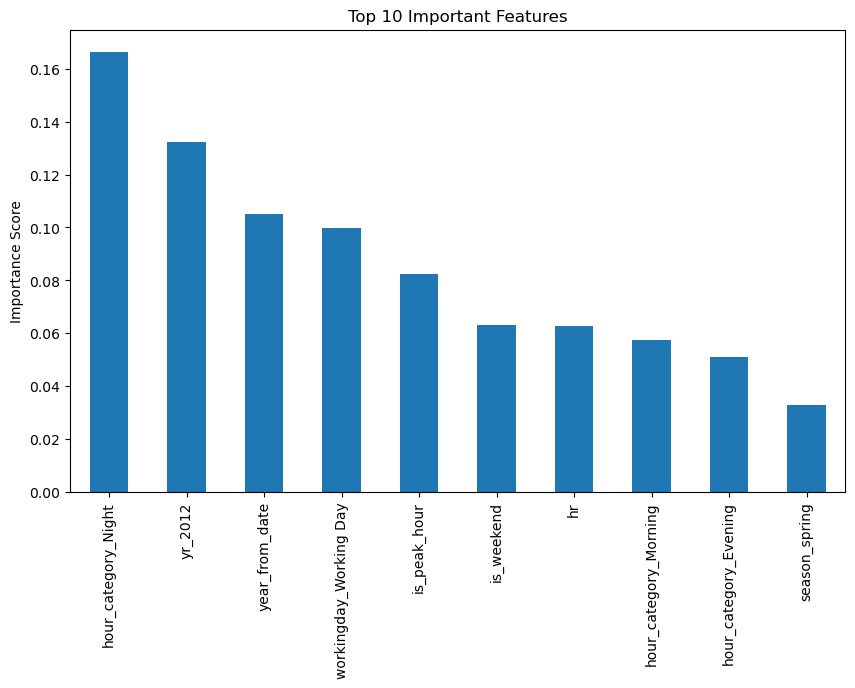

In [71]:
feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

#### 1) The night hour category perfectly helps in detecting low demands hence detecting lower rental period.
#### 2) The year 2012 indicates sale during 2012th year.
#### 3) The year category helps in understanding pattern of bike rent from long term period range.
#### 4) The working day category helps in understanding holidays and working days rent totals.
#### 5) The peak hour like morning and evening tells about high demands for bike.

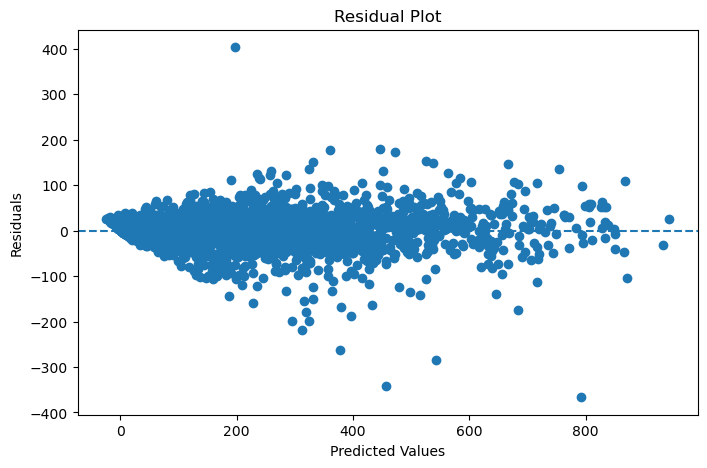

In [72]:
y_pred = best_xgb.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

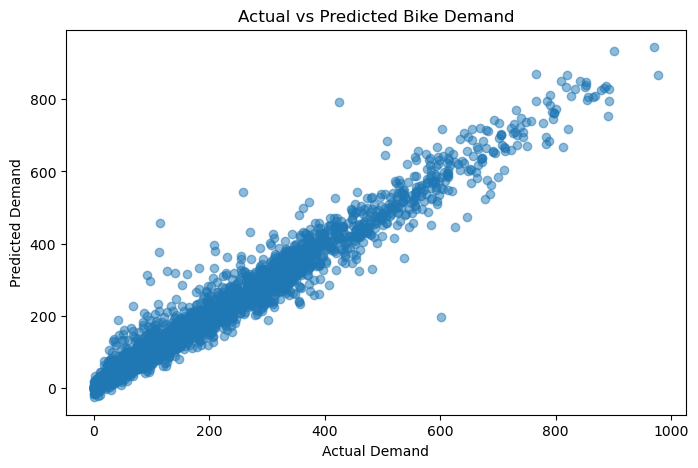

In [73]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Bike Demand")
plt.show()

## Comparing with Outlier Removed Dataset

In [74]:
df_outlier = df.copy()

In [75]:
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 
            'casual', 'registered', 'cnt']

In [76]:
for col in num_cols:
    df_outlier[col] = pd.to_numeric(df_outlier[col], errors='coerce')

In [77]:
Q1 = df_outlier[num_cols].quantile(0.25)
Q3 = df_outlier[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_outlier = df_outlier[~(
    (df_outlier[num_cols] < (Q1 - 1.5 * IQR)) |
    (df_outlier[num_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)]

In [78]:
X_o = df_outlier.drop('cnt', axis=1)
y_o = df_outlier['cnt']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_o, y_o, test_size=0.2, random_state=42
)
X_train_o, X_test_o = X_train_o.align(X_test_o, join='left', axis=1, fill_value=0)

In [79]:
xgb_outlier = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_outlier.fit(X_train_o, y_train_o)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [80]:
rmse_o, mae_o, r2_o = evaluate_model(xgb_outlier, X_test_o, y_test_o)
print("Outlier Removed Dataset")
print("RMSE:", rmse_o)
print("MAE:", mae_o)
print("R2 :", r2_o)

Outlier Removed Dataset
RMSE: 1.4224553024429696
MAE: 0.8271833658218384
R2 : 0.9998776316642761


In [81]:
comparison = pd.DataFrame({
    'Dataset': ['With Outliers', 'Without Outliers'],
    'RMSE': [34.30, rmse_o],
    'MAE': [21.01, mae_o],
    'R2': [0.9628, r2_o]
})
comparison

,Dataset,RMSE,MAE,R2
0,With Outliers,34.300000,21.010000,0.962800
1,Without Outliers,1.422455,0.827183,0.999878


#### Although removing outliers significantly improved numerical evaluation metrics, it also eliminated critical high-demand scenarios that are essential for real-world bike-sharing operations. Therefore, the model trained on the complete dataset with outliers was selected to ensure realistic and robust demand prediction.

# Model Deployment

In [82]:
import joblib
joblib.dump(best_xgb, "bike_rent_model.pkl")
joblib.dump(X_train.columns, "model_features.pkl")

['model_features.pkl']